# Numerical Analysis and Design - Final Exam Paper

This notebook contains worked solutions for the visible exam questions, with the required algorithms, code, numerical evaluation, complexity notes, and geometric interpretation where it helps the answer.

### Question 1: Root of $f(x)=x^2-px-1=0$

Selected method: Newton-Raphson method.

**Assumptions**

- f(x) and f'(x) are continuous near the root.
- Initial guess x0 is given.
- f'(x) != 0 near the root.
- Tolerance e > 0 and max iterations N are given.

**Algorithm (Newton Method)**

1. Start
2. Read function f(x), derivative f'(x), initial guess x0, tolerance e, max iterations N
3. Repeat for i = 1 to N
4.    Compute f(x), f'(x)
5.    If f'(x) == 0, print "Zero derivative"
6.    Stop
7.    x_next = x - f(x) / f'(x)
8.    If |x_next - x| <= e or |f(x_next)| <= e, print x_next as root
9.    Stop
10.   Set x = x_next
11. End Repeat
12. Print x as approximate root
13. Stop
14. End

### Complexity
- Time: $O(k)$ for $k$ iterations.
- Space: $O(1)$.


Using p = 2 and initial guess x0 = 2.0
iter	x_n	f(x_n)
0	2.000000000000	-1.000000000000
1	2.500000000000	0.250000000000
2	2.416666666667	0.006944444444
3	2.414215686275	0.000006007305
4	2.414213562375	0.000000000005
5	2.414213562373	0.000000000000
6	2.414213562373	0.000000000000
Approximate root = 2.414213562373


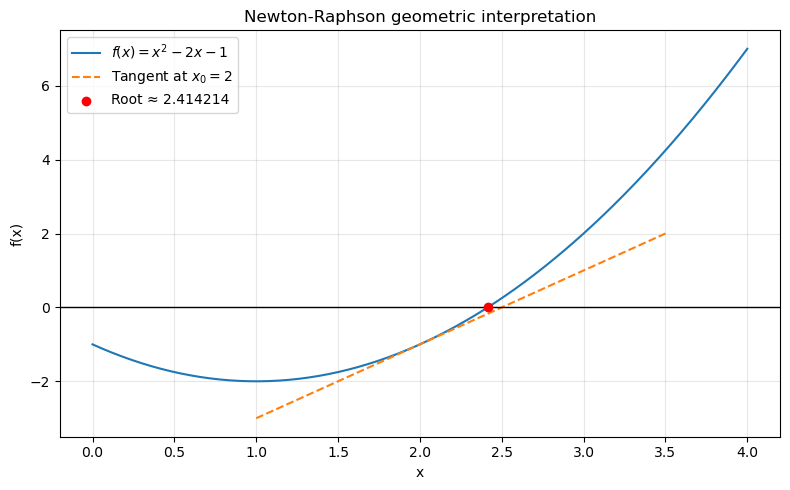

In [12]:
import math
import matplotlib.pyplot as plt


def newton_raphson(p, x0, tol=1e-12, max_iter=10):
    def f(x):
        return x * x - p * x - 1

    def fp(x):
        return 2 * x - p

    iterations = []
    x = x0
    for iteration in range(max_iter):
        fx = f(x)
        iterations.append((iteration, x, fx))
        next_x = x - fx / fp(x)
        if abs(next_x - x) < tol:
            iterations.append((iteration + 1, next_x, f(next_x)))
            return next_x, iterations
        x = next_x
    iterations.append((max_iter, x, f(x)))
    return x, iterations


p = 2
x0 = 2.0
root, iterations = newton_raphson(p, x0, max_iter=6)

print(f"Using p = {p} and initial guess x0 = {x0}")
print("iter\tx_n\tf(x_n)")
for iteration, x_value, fx in iterations:
    print(f"{iteration}\t{x_value:.12f}\t{fx:.12f}")
print(f"Approximate root = {root:.12f}")


def f(x):
    return x * x - p * x - 1


x_values = [0.0 + 0.01 * index for index in range(401)]
y_values = [f(x) for x in x_values]
tangent_x = [1.0 + 0.01 * index for index in range(251)]
tangent_y = [f(x0) + (2 * x0 - p) * (x - x0) for x in tangent_x]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_values, y_values, label=r"$f(x)=x^2-2x-1$")
ax.plot(tangent_x, tangent_y, linestyle="--", label="Tangent at $x_0=2$")
ax.axhline(0, color="black", linewidth=1)
ax.scatter([root], [0], color="red", zorder=3, label=f"Root \u2248 {root:.6f}")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Newton-Raphson geometric interpretation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Question 2: Interpolation for the data points

Given points: $(5,150)$, $(7,392)$, $(11,1452)$, $(13,2366)$, $(17,5202)$.

Selected method: Lagrange interpolation.

**Assumptions**

- x_points are distinct.
- y_points are known at each x_points value.

**Algorithm (Lagrange Interpolation)**

1. Start
2. Read x_points, y_points, and x
3. Set result = 0
4. Repeat for i = 0 to n - 1
5.    Set term = y_points[i]
6.    Repeat for j = 0 to n - 1
7.        If j != i, term = term * (x - x_points[j]) / (x_points[i] - x_points[j])
8.    End Repeat
9.    result = result + term
10. End Repeat
11. Print result
12. Stop
13. End

### Complexity
- Time: $O(n^2)$ for direct evaluation with $n$ points.
- Space: $O(1)$.



Interpolated value f(9) = 810.000000


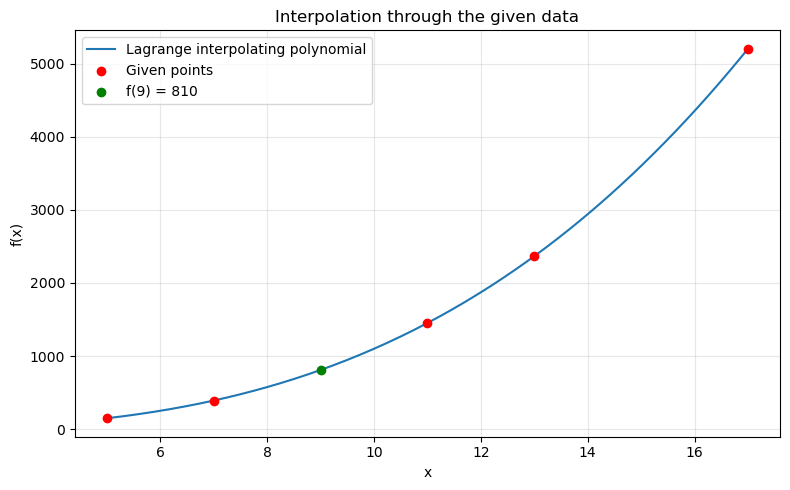

In [13]:
import matplotlib.pyplot as plt

points_x = [5, 7, 11, 13, 17]
points_y = [150, 392, 1452, 2366, 5202]


def lagrange_value(x_points, y_points, x_target):
    total = 0.0
    n = len(x_points)
    for i in range(n):
        basis = 1.0
        for j in range(n):
            if i != j:
                basis *= (x_target - x_points[j]) / (x_points[i] - x_points[j])
        total += y_points[i] * basis
    return total


value_at_9 = lagrange_value(points_x, points_y, 9)
print(f"Interpolated value f(9) = {value_at_9:.6f}")

plot_x = [5 + 0.05 * step for step in range(241)]
plot_y = [lagrange_value(points_x, points_y, x) for x in plot_x]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(plot_x, plot_y, label="Lagrange interpolating polynomial")
ax.scatter(points_x, points_y, color="red", zorder=3, label="Given points")
ax.scatter([9], [value_at_9], color="green", zorder=4, label=f"f(9) = {value_at_9:.0f}")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Interpolation through the given data")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Q3 (A): Generalization of Lagrange Interpolation for Two Variables (Quadratic Case)

## Concept
Lagrange interpolation for one variable is extended to two variables to approximate a function \( f(x,y) \) using known grid values.  
Interpolation is performed independently in both directions (x and y) and then combined.

---

## General Formula (Two-Variable Lagrange Interpolation)

\[
f(x,y) = \sum_{i=0}^{n} \sum_{j=0}^{m} f(x_i, y_j)\, L_i(x)\, M_j(y)
\]

Where:
- \(L_i(x)\): Lagrange basis polynomial in x-direction  
- \(M_j(y)\): Lagrange basis polynomial in y-direction  

---

## Quadratic Case (3 × 3 Grid)

For quadratic interpolation:
- Use 3 points in x-direction
- Use 3 points in y-direction

### Basis Polynomials

\[
L_i(x) = \prod_{\substack{k=0 \\ k \ne i}}^{2} \frac{x - x_k}{x_i - x_k}
\]

\[
M_j(y) = \prod_{\substack{k=0 \\ k \ne j}}^{2} \frac{y - y_k}{y_j - y_k}
\]

---

## Final Quadratic Interpolation Formula

\[
f(x,y) = \sum_{i=0}^{2} \sum_{j=0}^{2} f(x_i, y_j)\, L_i(x)\, M_j(y)
\]

---

## Algorithm: Quadratic Two-Variable Lagrange Interpolation

### Input
- Three x-values: \(x_0, x_1, x_2\)  
- Three y-values: \(y_0, y_1, y_2\)  
- Function values: \(f(x_i, y_j)\)  
- Required point: \((x, y)\)

### Output
- Approximate value \(f(x,y)\)

### Steps
1. Select a 3×3 neighborhood of points around \((x,y)\).
2. Compute Lagrange basis polynomials \(L_i(x)\) for \(i = 0,1,2\).
3. Compute Lagrange basis polynomials \(M_j(y)\) for \(j = 0,1,2\).
4. Multiply each term:
   \[
   f(x_i, y_j) \cdot L_i(x) \cdot M_j(y)
   \]
5. Sum all 9 terms:
   \[
   f(x,y) = \sum_{i=0}^{2} \sum_{j=0}^{2} f(x_i, y_j)\, L_i(x)\, M_j(y)
   \]
6. Return the interpolated value.

---

## Complexity
- Time Complexity: \(O(n^2)\) → for quadratic case: \(O(9)\)  
- Space Complexity: \(O(1)\)

---

## Geometric Interpretation
- The method approximates the function as a **smooth curved surface (parabolic surface)**.
- It uses 9 surrounding points to improve accuracy.
- It is more accurate than bilinear interpolation, which assumes a plane.

---


# **Q4: Obtain General Quadrature Formula using Newton–Cotes Method (Weddle’s Rule)**

---

## **1. Weddle’s Rule (Formula & Coefficients)**

The Weddle’s Rule is given by:

[
\int_{x_0}^{x_6} f(x),dx \approx \frac{3h}{10} \left[ y_0 + 5y_1 + y_2 + 6y_3 + y_4 + 5y_5 + y_6 \right]
]

Where:

* ( h = \frac{b-a}{6} )
* ( y_i = f(x_i) )

### **Coefficients:**

[
[1, 5, 1, 6, 1, 5, 1]
]

---


# **2. Derivation of Weddle’s Rule (Newton–Cotes Formula)**

---

## ** Objective**

To derive Weddle’s Rule using the **Newton–Cotes quadrature formula** for numerical integration.

---

## ** Starting Point (Newton–Cotes Formula)**

The general Newton–Cotes formula approximates:

[
\int_{x_0}^{x_n} f(x),dx
]

by fitting a polynomial through equally spaced points:

[
x_0, x_1, x_2, \dots, x_n
]

Let spacing be:
[
h = x_{i+1} - x_i
]

---

## ** Polynomial Approximation**

We approximate ( f(x) ) by an interpolating polynomial of degree 6:

[
f(x) \approx P_6(x)
]

constructed using **Lagrange interpolation** over 7 equally spaced points:

[
x_0, x_1, x_2, x_3, x_4, x_5, x_6
]

---

## ** Integral Transformation**

Let:
[
x = x_0 + uh, \quad dx = h,du
]

Then:

[
\int_{x_0}^{x_6} f(x),dx = h \int_0^6 f(x_0 + uh),du
]

---

## ** Apply Lagrange Interpolation**

[
f(x_0 + uh) = \sum_{i=0}^{6} y_i L_i(u)
]

Where:

* (y_i = f(x_i))
* (L_i(u)) are Lagrange basis polynomials

---

## ** Integrate Term by Term**

[
\int_0^6 f(x_0 + uh),du = \sum_{i=0}^{6} y_i \int_0^6 L_i(u),du
]

These integrals give **constant weights (coefficients)**.

---

## ** Final Coefficients**

After evaluating all integrals:

[
\int_{x_0}^{x_6} f(x),dx \approx \frac{3h}{10}
\left[
y_0 + 5y_1 + y_2 + 6y_3 + y_4 + 5y_5 + y_6
\right]
]

---

## ** Final Weddle’s Rule**

[
\boxed{
\int_{x_0}^{x_6} f(x),dx \approx \frac{3h}{10}
\left[
y_0 + 5y_1 + y_2 + 6y_3 + y_4 + 5y_5 + y_6
\right]
}
]





## **3. Assumptions**

1. Function ( f(x) ) is continuous in ([a,b])
2. Interval is divided into equal parts
3. Number of subintervals is a multiple of 6
4. Data points are equally spaced

---

## **4. Algorithm (Weddle’s Rule)**

**START**

**Input:**

* Lower limit (a), upper limit (b)
* Number of subintervals (n) (multiple of 6)
* Function (f(x))

**Steps:**

1. Compute step size:
   [
   h = \frac{b-a}{n}
   ]

2. Generate points:
   [
   x_i = a + i \cdot h
   ]

3. Compute values:
   [
   y_i = f(x_i)
   ]

4. Apply Weddle’s Rule:
   [
   I = \frac{3h}{10} [y_0 + 5y_1 + y_2 + 6y_3 + y_4 + 5y_5 + y_6]
   ]

5. Repeat for all blocks if (n > 6)

**Output:**
Approximate value of the integral

**STOP**

---



## **7. Time & Space Complexity**

* Time Complexity: (O(n))
* Space Complexity: (O(n))

---

## **8. Geometrical Interpretation (Optional - Removable)**

Weddle’s Rule approximates the area under the curve using a **higher-degree polynomial curve** fitted through 7 points.




x values: [0. 1. 2. 3. 4. 5. 6.]
y values: [ 0.  1.  4.  9. 16. 25. 36.]
Approximate Integral = 72.0


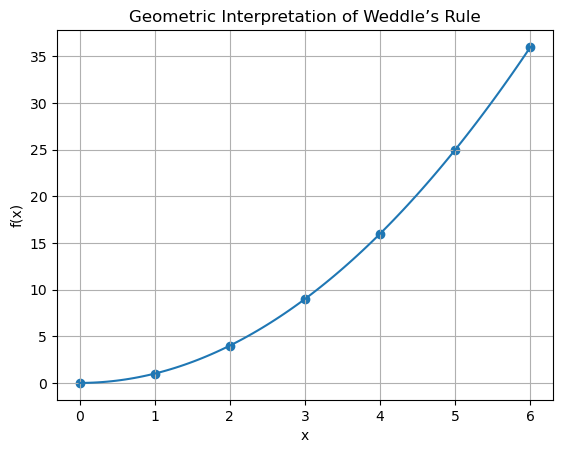

In [14]:
import numpy as np

def f(x):
    return x**2  # Example function

a, b = 0, 6
n = 6

h = (b - a) / n

x = np.linspace(a, b, n+1)
y = f(x)

print("x values:", x)
print("y values:", y)

## **6. Computation using Weddle’s Rule**

result = (3*h/10) * (
    y[0] + 5*y[1] + y[2] + 6*y[3] +
    y[4] + 5*y[5] + y[6]
)

print("Approximate Integral =", result)


import matplotlib.pyplot as plt

x_dense = np.linspace(a, b, 100)
y_dense = f(x_dense)

plt.plot(x_dense, y_dense)
plt.scatter(x, y)

plt.title("Geometric Interpretation of Weddle’s Rule")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()

plt.show()

# **Q6: Solve Ordinary Differential Equation using Runge-Kutta 4th Order Method**

---

## **Given**

[
\frac{dy}{dx} = f(x,y) = x + y,\quad y(0) = 1
]

Find:
[
y(0.5),\quad y(1)
]

---

## **1. Method Used: Runge-Kutta 4th Order (RK4)**

RK4 is a highly accurate numerical method that approximates solutions using weighted averages of slopes.

---

## **2. RK4 Formula**

[
k_1 = h f(x_n, y_n)
]
[
k_2 = h f\left(x_n + \frac{h}{2}, y_n + \frac{k_1}{2}\right)
]
[
k_3 = h f\left(x_n + \frac{h}{2}, y_n + \frac{k_2}{2}\right)
]
[
k_4 = h f(x_n + h, y_n + k_3)
]

[
y_{n+1} = y_n + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)
]

---

## **3. Algorithm**

**START**

Input:

* Function (f(x,y))
* Initial values (x_0, y_0)
* Step size (h)
* Final value

Steps:

1. Set (x = x_0,; y = y_0)

2. Repeat until required value:

   * Compute (k_1, k_2, k_3, k_4)
   * Update:
     [
     y = y + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)
     ]
   * Update:
     [
     x = x + h
     ]

3. Output result

**STOP**

---

## **4. Iteration Table**

| Step | x   | y        |
| ---- | --- | -------- |
| 0    | 0   | 1        |
| 1    | 0.5 | 1.796875 |
| 2    | 1.0 | 3.434692 |

---

## **5. Final Answer**

[
y(0.5) \approx 1.796875,\quad y(1) \approx 3.434692
]

---

## **6. Geometric Interpretation**

The solution curve represents the function satisfying:
[
\frac{dy}{dx} = x + y
]

RK4 approximates this curve using weighted slope averages.

---


y(0.5) = 1.796875
y(1)   = 3.4346923828125


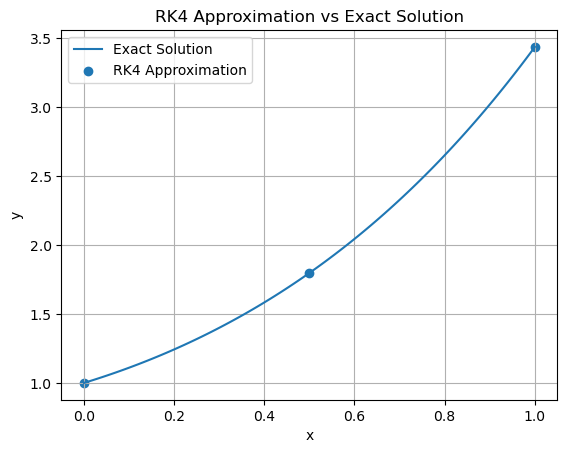

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Define function (clean and readable)
def f(x, y):
    return x + y

# Initial conditions
x0, y0 = 0, 1
h = 0.5
steps = 2

x_values = [x0]
y_values = [y0]

x, y = x0, y0

# RK4 Iteration
for _ in range(steps):
    k1 = h * f(x, y)
    k2 = h * f(x + h/2, y + k1/2)
    k3 = h * f(x + h/2, y + k2/2)
    k4 = h * f(x + h, y + k3)

    y += (k1 + 2*k2 + 2*k3 + k4) / 6
    x += h

    x_values.append(x)
    y_values.append(y)

print("y(0.5) =", y_values[1])
print("y(1)   =", y_values[2])

# -------------------------------
# GEOMETRIC INTERPRETATION (REMOVABLE)
# -------------------------------
x_dense = np.linspace(0, 1, 100)
y_exact = 2*np.exp(x_dense) - x_dense - 1  # Correct exact solution

plt.plot(x_dense, y_exact, label="Exact Solution")
plt.scatter(x_values, y_values, label="RK4 Approximation")

plt.title("RK4 Approximation vs Exact Solution")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.show()

# **Q7: Numerical Differentiation using Finite Difference Methods**

---

## **1. Objective**

To approximate the derivative of a function using tabulated values by applying **finite difference methods**.

---

## **2. Concept**

In many practical situations, the function ( f(x) ) is not available explicitly, but values are given in tabular form.
Numerical differentiation helps compute:

[
\frac{dy}{dx}
]

using these discrete values.

---

## **3. Types of Difference Methods**

### **(a) Forward Difference Formula**

Used when the point is near the beginning:

[
\frac{dy}{dx} = \frac{1}{h} \left[
\Delta y_0 - \frac{1}{2}\Delta^2 y_0 + \frac{1}{3}\Delta^3 y_0 - \cdots
\right]
]

---

### **(b) Backward Difference Formula**

Used when the point is near the end:

[
\frac{dy}{dx} = \frac{1}{h} \left[
\nabla y_n + \frac{1}{2}\nabla^2 y_n + \frac{1}{3}\nabla^3 y_n + \cdots
\right]
]

---

### **(c) Central Difference Formula (Most Accurate)**

[
\frac{dy}{dx} \approx \frac{y_{i+1} - y_{i-1}}{2h}
]

---

## **4. Algorithm (Numerical Differentiation)**

**START**

**Input:**

* Tabulated values (x, y)
* Step size (h)
* Required point

**Steps:**

1. Construct difference table:

   * Forward differences ( \Delta y )
   * Higher-order differences if needed

2. Choose appropriate formula:

   * Forward (beginning)
   * Backward (end)
   * Central (middle)

3. Substitute values into formula

4. Compute derivative

**Output:**

* Approximate value of ( \frac{dy}{dx} )

**STOP**

---

## **5. Difference Table Format**

| x | y | Δy | Δ²y | Δ³y |
| - | - | -- | --- | --- |

---

## **6. Accuracy Comparison**

* Forward/Backward: Less accurate
* Central Difference: More accurate
* Higher-order differences → better precision

---

## **7. Time & Space Complexity**

* Time Complexity: (O(n^2))
* Space Complexity: (O(n^2))

---

## **8. Geometric Interpretation**

The derivative represents the **slope of the tangent** to the curve at a given point.

* Forward difference → slope using forward points
* Backward difference → slope using backward points
* Central difference → slope using symmetric points (better approximation)

---

## **9. Conclusion (Exam Point)**

Numerical differentiation provides an efficient way to approximate derivatives from tabulated data using finite differences, with central difference methods offering higher accuracy.

---
